In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

In [2]:
df_complete = pd.read_csv('VELSIPITY_AFF_MULTIPLI_prepared_prepared_prepared.csv')
df_complete.shape

(1800066, 68)

In [13]:
df=df_complete.sample(n=5000,random_state=42)
df2=df_complete.sample(n=50000,random_state=42)

### Features

In [20]:
# Excluimos IDs, fechas y la variable de clasificación 'ATSEG'
features = [
    'UC_TRX', 'ORAL_TRX', 'IL23_TRX', 'BRAND1_TRX', 'BRAND2_TRX',
    'SAMPLES', 'COPAY', 'DIRECTMAIL', 'SPK', 'DETAILS',
    'UC_TRX_R4_16SUM', 'ORAL_NBRX_R4_29SUM', 'IL23_NBRX_R4_29SUM',
    'BRAND1_NTB_GIDX', 'BRAND2_NTB_GIDX'
]

X = df[features].copy()
X = X.fillna(0)
X2 = df2[features].copy()
X2 = X2.fillna(0)

scaler = StandardScaler()
X2_scaled = scaler.fit_transform(X2)  # GMM
X_scaled = scaler.transform(X)  # Dendrograma

### Hierarchical Clustering

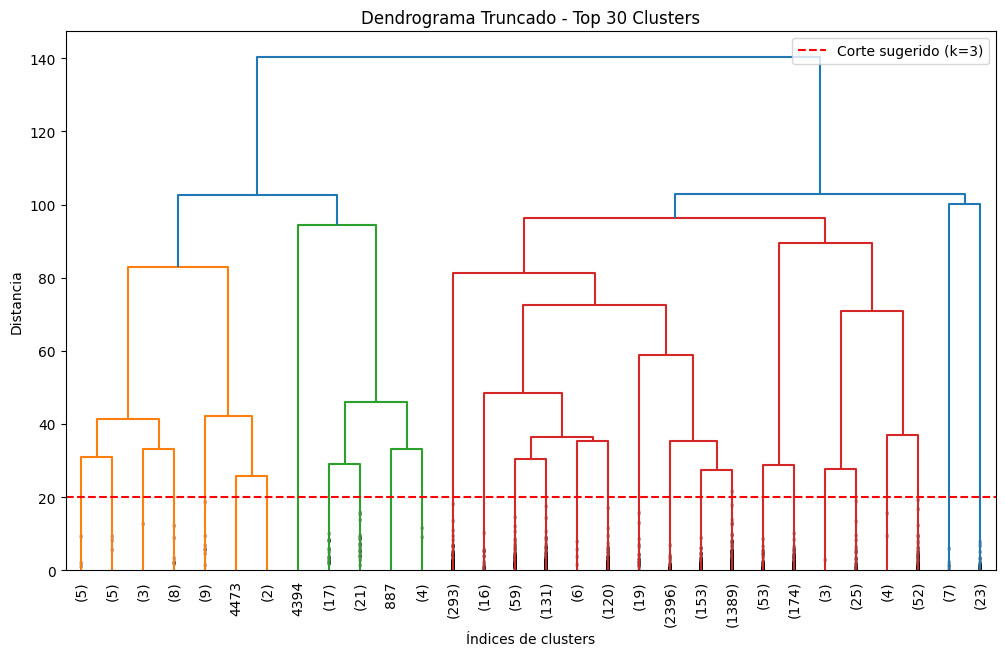

In [15]:
# Calcular matriz de distancia y linkage
linkage_matrix = linkage(X_scaled, method='ward')

plt.figure(figsize=(12, 7))
dendrogram(linkage_matrix, truncate_mode='lastp', p=30,
           leaf_rotation=90., leaf_font_size=10., show_contracted=True)
plt.axhline(y=20, color='r', linestyle='--', label='Corte sugerido (k=3)')
plt.title('Dendrograma Truncado - Top 30 Clusters')
plt.xlabel('Índices de clusters')
plt.ylabel('Distancia')
plt.legend()
plt.show()

### Gaussian Mixture Models (GMM)

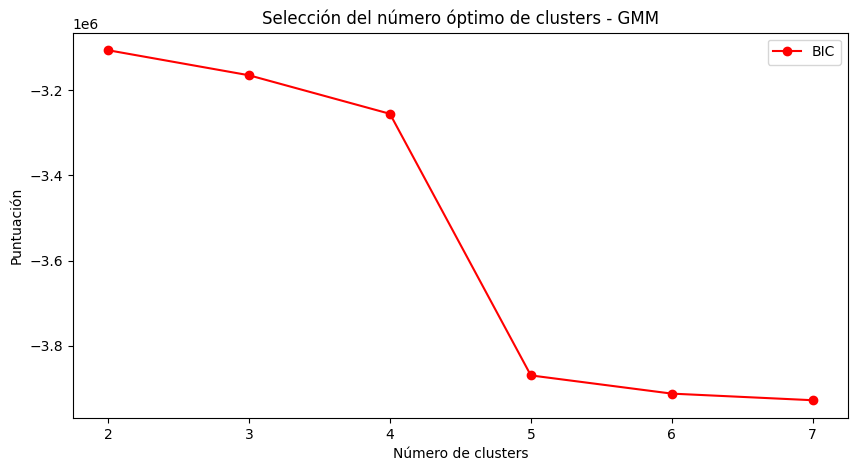

In [28]:
# Método del codo para GMM
n_components_range = range(2, 8)
bics = []

for n in n_components_range:
    gmm = GaussianMixture(n_components=n, random_state=42)
    gmm.fit(X2_scaled)
    bics.append(gmm.bic(X2_scaled))

plt.figure(figsize=(10, 5))
plt.plot(n_components_range, bics, 'ro-', label='BIC')
plt.xlabel('Número de clusters')
plt.ylabel('Puntuación')
plt.legend()
plt.title('Selección del número óptimo de clusters - GMM')
plt.show()

In [39]:
gmm = GaussianMixture(n_components=5, random_state=42, covariance_type='full')
df2['cluster_gmm'] = gmm.fit_predict(X2_scaled)

# También para la muestra pequeña (opcional)
df['cluster_gmm'] = gmm.predict(X_scaled)

print("Distribución de clusters GMM:")
print(df2['cluster_gmm'].value_counts().sort_index())

Distribución de clusters GMM:
cluster_gmm
0    43003
1      343
2       60
3     3004
4     3590
Name: count, dtype: int64


/var/folders/gr/dhf3yhtd6jj5nvkd804gsrh80000gn/T/ipykernel_71270/2373745402.py:22: UserWarning: 
The palette list has fewer values (3) than needed (5) and will cycle, which may produce an uninterpretable plot.
  sns.scatterplot(data=sample_df, x='UC_TRX_R4_16SUM', y='DETAILS',


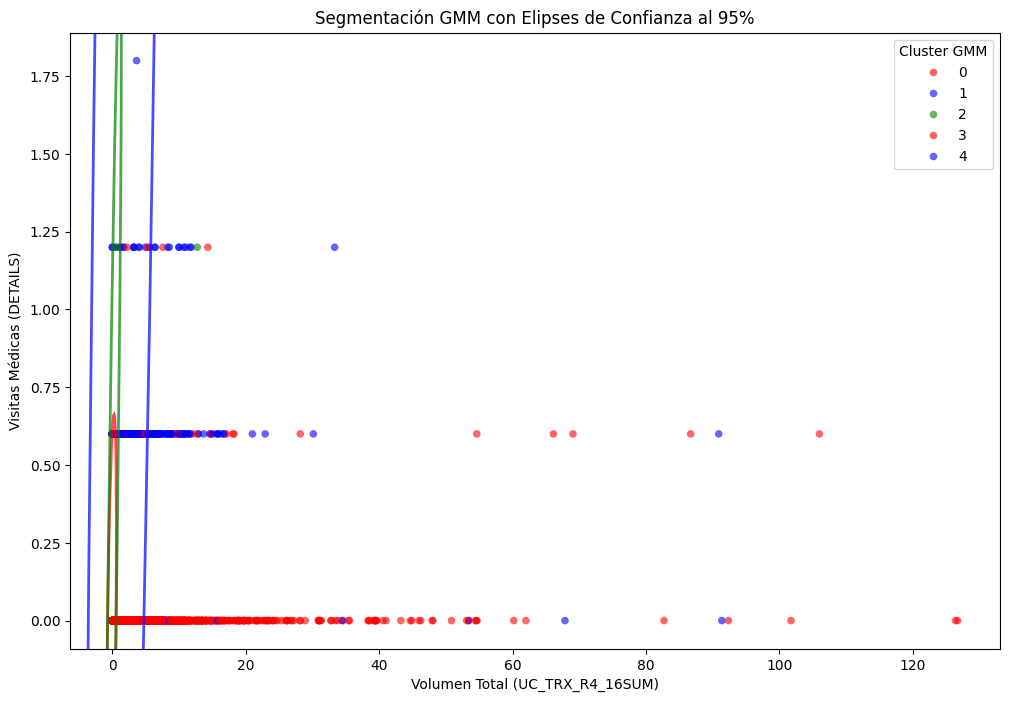

In [40]:
def plot_gmm_ellipses(gmm, X, ax, colors, alpha=0.3):
    """Dibuja elipses de confianza al 95% para cada componente GMM"""
    for i, color in enumerate(colors):
        mean = gmm.means_[i][:2]
        cov = gmm.covariances_[i][:2, :2]
        
        # Calcular elipse al 95% de confianza (chi2 con df=2)
        v, w = np.linalg.eigh(cov)
        v = 2 * np.sqrt(2.447 * v) 
        angle = np.arctan2(w[1, 0], w[0, 0])
        ell = Ellipse(xy=mean, width=v[0], height=v[1], angle=np.degrees(angle),
                      edgecolor=color, facecolor='none', linewidth=2, alpha=0.7)
        ax.add_patch(ell)

# Muestrear para evitar overplotting
sample_df = df2.sample(n=5000, random_state=42)

plt.figure(figsize=(12, 8))
ax = plt.gca()
colors = ['red', 'blue', 'green']

sns.scatterplot(data=sample_df, x='UC_TRX_R4_16SUM', y='DETAILS', 
                hue='cluster_gmm', palette=colors, alpha=0.6, s=30, edgecolor='none')

# Dibujar elipses de confianza (usa las medias y covarianzas del GMM original)
plot_gmm_ellipses(gmm, X2_scaled, ax, colors)

plt.title('Segmentación GMM con Elipses de Confianza al 95%')
plt.xlabel('Volumen Total (UC_TRX_R4_16SUM)')
plt.ylabel('Visitas Médicas (DETAILS)')
plt.legend(title='Cluster GMM')
plt.show()

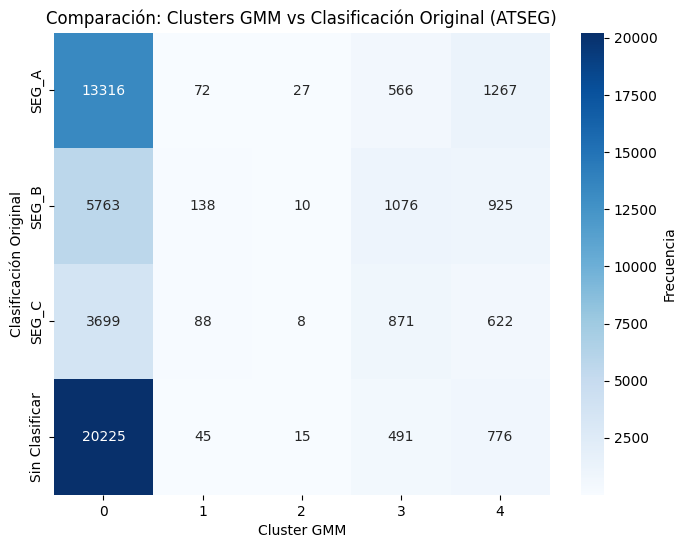

In [ ]:
import seaborn as sns

crosstab = pd.crosstab(df2['ATSEG'].fillna('Sin Clasificar'), df2['cluster_gmm'])
plt.figure(figsize=(8, 6))
sns.heatmap(crosstab, annot=True, fmt='d', cmap='Blues', cbar_kws={'label': 'Frecuencia'})
plt.title('Comparación: Clusters GMM vs ATSEG')
plt.ylabel('Clasificación Original')
plt.xlabel('Cluster GMM')
plt.show()